# Trama Urbana — Fast Prompting en Acción

## Introducción
Trama Urbana es un emprendimiento ficticio de remeras y buzos urbanos. El problema elegido es la dificultad para preparar contenido de Instagram con textos claros y una estética consistente cuando una sola persona dispone de poco tiempo y recursos.

La solución propuesta utiliza modelos generativos existentes para redactar publicaciones y diseñar instrucciones de imagen. No se entrena un modelo propio. El alcance final sigue siendo tres publicaciones: presentación de marca, presentación de una remera e idea de combinación. Esta POC se concentra en la publicación de una remera para comparar configuraciones sobre el mismo caso antes de extenderlas.

La viabilidad se apoya en Python, una notebook y herramientas existentes. Se estiman entre seis y ocho horas de trabajo académico. La revisión de resultados registrados no necesita clave ni consultas. Se probaron los prompts en ChatGPT web y se incorporaron sus respuestas reales a la notebook. El modo manual permite repetir ese procedimiento; la API queda como extensión opcional con acceso y saldo propios. Los fondos de imagen se pueden generar por separado con una herramienta disponible y complementar con fotos reales. No se automatizan publicaciones ni se garantiza un aumento de ventas.

## Objetivos
- Implementar una POC que construya, ejecute o reproduzca y evalúe prompts.
- Comparar una instrucción básica, otra contextualizada y otra con ejemplos.
- Obtener un texto y un prompt de imagen reutilizables en una sola respuesta.
- Registrar consultas, tokens y latencia cuando se use la API.
- Analizar mejoras y límites respecto de la Preentrega 1.

## Metodología
1. Fijar los mismos datos del producto y criterios de evaluación.
2. Construir tres variantes conservando la tarea y el formato solicitado.
3. Ejecutar cada variante en una conversación nueva de ChatGPT y registrar su respuesta original. La interfaz no permite verificar aquí el identificador del modelo; se documenta esa limitación.
4. Validar la estructura y algunos requisitos con Python, sin otra consulta.
5. Revisar manualmente fidelidad, tono y utilidad; seleccionar una variante provisional.
6. Conservar resultados para no repetir solicitudes idénticas.

Se utilizó un solo producto y una respuesta real por variante: tres consultas en total, sin repreguntas. No se trata de un experimento estadístico: cambiar varias instrucciones a la vez y disponer de una muestra pequeña impide atribuir causalmente las diferencias a una sola técnica.

## Herramientas y técnicas
Python 3 y Jupyter Notebook; Google Colab es una alternativa para abrir el archivo. La conexión opcional usa HTTPS y la API Responses con bibliotecas estándar de Python.

En esta POC, “Fast Prompting” se operacionaliza como instrucciones concisas, contexto suficiente y pocas consultas. Se aplican **zero-shot**, **asignación de rol**, **contexto y restricciones**, **few-shot con dos ejemplos**, **salida JSON** y **plantillas reutilizables**. La consigna no detalla una taxonomía específica del curso; no se presupone que esta definición sea una cita de su material.

Los ejemplos orientan el tono; el JSON facilita procesar la respuesta; las restricciones evitan solicitar información comercial desconocida. La descomposición se realiza en funciones locales, en lugar de encadenar llamadas. No se solicita razonamiento interno del modelo.

## Procedencia y estado de la evidencia
El 10 de septiembre de 2026 (Argentina) se enviaron los tres prompts de esta notebook a ChatGPT web en conversaciones independientes. Se guardaron las respuestas originales, sin correcciones, en `experimento_real.json` y también dentro de la notebook para que funcione al abrirla sola en Colab.

**Modo predeterminado: REGISTRO.** Reanaliza respuestas reales ya obtenidas; no hace nuevas consultas. **Modo MANUAL:** imprime cada prompt, el usuario lo envía a ChatGPT y pega la respuesta para que Python la evalúe. Este es un flujo semiautomático con transferencia humana explícita, sin API. La notebook no controla el navegador de ChatGPT.

La API se conserva como extensión opcional no validada contra el servicio. No es el mecanismo con el que se realizó este experimento. La imagen de la Preentrega 1 se conserva como evidencia previa de texto a imagen.

## 1. Configuración y uso
Para ver la comparación comprobada, dejar `MODO = "REGISTRO"` y ejecutar todas las celdas. No requiere instalaciones adicionales ni claves.

Para generar y evaluar nuevas respuestas sin API, cambiar a `MODO = "MANUAL"`. La celda 5 imprime un prompt por vez: copiarlo en un chat nuevo de ChatGPT, copiar la respuesta completa y pegarla cuando Python la solicite; finalizar la entrada con una línea que diga `FIN`. En Colab se pueden pegar líneas sucesivas en las entradas de texto. No se corrige el contenido antes de evaluarlo.

`MODO = "API"` es opcional; requiere `MODELO` y clave propia. No es necesario para consultar ni repetir manualmente la POC. Las tarifas configurables se usan solo en ese modo. No se conoce el consumo en tokens de las pruebas web y no se inventa.

In [1]:
import json, os, re, hashlib, time, getpass
from pathlib import Path
from urllib import request, error
from datetime import datetime, timezone

MODO = "REGISTRO"  # REGISTRO, MANUAL o API (opcional).
MODELO = os.environ.get("OPENAI_MODEL", "")
PRECIO_ENTRADA_USD_MILLON = None
PRECIO_SALIDA_USD_MILLON = None
MAX_CONSULTAS = 3
MAX_OUTPUT_TOKENS = 1200
CACHE_DIR = Path(".cache_trama")
# Conserva el contador si se vuelve a ejecutar esta celda en el mismo kernel.
ESTADO = globals().get("ESTADO", {"intentos": 0})
assert MODO in {"REGISTRO", "MANUAL", "API"}
print("Modo:", MODO)
print("Máximo de intentos API en esta sesión:", MAX_CONSULTAS)

Modo: REGISTRO
Máximo de intentos API en esta sesión: 3


## 2. Contexto y construcción de prompts
Las tres variantes piden el mismo producto, texto de 50 a 80 palabras sin contar hashtags y el mismo formato. La versión contextualizada explicita audiencia, rol y límites; la few-shot agrega dos ejemplos breves de tono. Los ejemplos no son textos finales de 50 a 80 palabras.

In [2]:
DATOS = {
    "marca": "Trama Urbana", "producto": "remera",
    "color": "negra", "diseno": "lisa", "manga": "corta"
}
FORMATO = (
    'Devolvé solo JSON con exactamente tres claves: "texto" (string de 50 a 80 '
    'palabras, sin hashtags), "hashtags" (lista de 1 a 3 strings que comiencen '
    'con #) y "prompt_imagen" (string). El texto debe nombrar la marca, '
    'describir la prenda, sugerir una combinación y pedir consultas por mensaje privado. '
    'El prompt de imagen debe describir un fondo cuadrado, beige, negro y blanco, '
    'con espacio central libre, sin prendas, personas, texto ni logotipos.'
)
def construir_prompts(datos):
    ficha = json.dumps(datos, ensure_ascii=False)
    base = "Escribí una publicación para Instagram a partir de estos datos: " + ficha
    contexto = (
        "Actuá como redactor de Trama Urbana. Público de 18 a 30 años; tono cercano "
        "y claro, en español rioplatense. Usá únicamente la ficha como fuente de "
        "características. No inventes precio, material, talles, stock, descuentos, "
        "envíos ni calidad. La imagen será un fondo; el producto real se agregaría "
        "con una fotografía. Ficha: " + ficha
    )
    ejemplos = (
        '\nEjemplos parciales de tono (no copiar productos ni confundirlos con la ficha): '
        '\nEntrada: gorra azul. Salida: "Sumá un toque de azul a tu look. '
        'Combiná esta gorra con una remera lisa. Escribinos por mensaje privado." '
        '\nEntrada: pantalón gris. Salida: "Armá tu próxima combinación con este '
        'pantalón gris y un buzo negro. Consultanos por mensaje privado." '
        '\nAhora resolvé la tarea de la ficha; respetá la extensión del texto final.'
    )
    return {"A_basico": base + "\n" + FORMATO,
            "B_contexto": contexto + "\n" + FORMATO,
            "C_few_shot": contexto + ejemplos + "\n" + FORMATO}

PROMPTS = construir_prompts(DATOS)
for nombre, prompt in PROMPTS.items():
    print("\n" + nombre + " (" + str(len(prompt)) + " caracteres; no tokens):")
    print(prompt)


A_basico (611 caracteres; no tokens):
Escribí una publicación para Instagram a partir de estos datos: {"marca": "Trama Urbana", "producto": "remera", "color": "negra", "diseno": "lisa", "manga": "corta"}
Devolvé solo JSON con exactamente tres claves: "texto" (string de 50 a 80 palabras, sin hashtags), "hashtags" (lista de 1 a 3 strings que comiencen con #) y "prompt_imagen" (string). El texto debe nombrar la marca, describir la prenda, sugerir una combinación y pedir consultas por mensaje privado. El prompt de imagen debe describir un fondo cuadrado, beige, negro y blanco, con espacio central libre, sin prendas, personas, texto ni logotipos.

B_contexto (869 caracteres; no tokens):
Actuá como redactor de Trama Urbana. Público de 18 a 30 años; tono cercano y claro, en español rioplatense. Usá únicamente la ficha como fuente de características. No inventes precio, material, talles, stock, descuentos, envíos ni calidad. La imagen será un fondo; el producto real se agregaría con una fotog

## 3. Respuestas reales registradas
Se conservaron exactamente los tres textos devueltos por ChatGPT web, junto con los prompts y el procedimiento. El registro está incorporado en esta celda para que abrir únicamente la notebook en Colab no requiera descargar archivos adicionales. El archivo `experimento_real.json` del repositorio ofrece los mismos datos para inspección.

La identidad exacta del modelo, temperatura, tokens y latencia de inferencia no fueron expuestos por la interfaz. El experimento es exploratorio; no se presenta como una comparación controlada entre modelos.

In [3]:
EXPERIMENTO = json.loads('{"fecha_registro_utc": "2026-09-11T01:37:57Z", "fecha_local": "2026-09-10", "herramienta": "ChatGPT, interfaz web", "modelo": null, "nota_modelo": "La interfaz no expuso un identificador verificable de modelo. No se presume un modelo a partir de la etiqueta ChatGPT Plus.", "procedimiento": "Tres conversaciones nuevas, una consulta por variante, sin correcciones ni repreguntas. Respuestas extraídas del texto visible de la página y conservadas sin edición. Experimento asistido por navegador; no ejecutado por la API de la notebook.", "consultas_web": 3, "consultas_api": 0, "tokens": null, "latencia_modelo": null, "respuestas": {"A_basico": {"prompt": "Escribí una publicación para Instagram a partir de estos datos: {\\"marca\\": \\"Trama Urbana\\", \\"producto\\": \\"remera\\", \\"color\\": \\"negra\\", \\"diseno\\": \\"lisa\\", \\"manga\\": \\"corta\\"}\\nDevolvé solo JSON con exactamente tres claves: \\"texto\\" (string de 50 a 80 palabras, sin hashtags), \\"hashtags\\" (lista de 1 a 3 strings que comiencen con #) y \\"prompt_imagen\\" (string). El texto debe nombrar la marca, describir la prenda, sugerir una combinación y pedir consultas por mensaje privado. El prompt de imagen debe describir un fondo cuadrado, beige, negro y blanco, con espacio central libre, sin prendas, personas, texto ni logotipos.", "raw": "{\\"texto\\":\\"Trama Urbana presenta una remera negra lisa de manga corta, un básico versátil para sumar estilo a cualquier look. Combinala con un jean azul y zapatillas blancas para un outfit urbano y relajado, o con pantalón sastrero para una propuesta más sofisticada. Una prenda simple, cómoda y fácil de usar todos los días. ¿Querés saber más? Consultanos por mensaje privado.\\",\\"hashtags\\":[\\"#TramaUrbana\\",\\"#RemeraNegra\\",\\"#EstiloUrbano\\"],\\"prompt_imagen\\":\\"Fondo cuadrado de estética urbana y minimalista, con paleta beige, negro y blanco, composición equilibrada y moderna, iluminación suave, texturas sutiles y espacio central amplio y completamente libre para colocar contenido posteriormente. Sin prendas, personas, texto, letras, tipografías, logotipos ni marcas.\\"}"}, "B_contexto": {"prompt": "Actuá como redactor de Trama Urbana. Público de 18 a 30 años; tono cercano y claro, en español rioplatense. Usá únicamente la ficha como fuente de características. No inventes precio, material, talles, stock, descuentos, envíos ni calidad. La imagen será un fondo; el producto real se agregaría con una fotografía. Ficha: {\\"marca\\": \\"Trama Urbana\\", \\"producto\\": \\"remera\\", \\"color\\": \\"negra\\", \\"diseno\\": \\"lisa\\", \\"manga\\": \\"corta\\"}\\nDevolvé solo JSON con exactamente tres claves: \\"texto\\" (string de 50 a 80 palabras, sin hashtags), \\"hashtags\\" (lista de 1 a 3 strings que comiencen con #) y \\"prompt_imagen\\" (string). El texto debe nombrar la marca, describir la prenda, sugerir una combinación y pedir consultas por mensaje privado. El prompt de imagen debe describir un fondo cuadrado, beige, negro y blanco, con espacio central libre, sin prendas, personas, texto ni logotipos.", "raw": "{\\n\\"texto\\": \\"En Trama Urbana, lo simple también tiene actitud. Esta remera negra lisa de manga corta es una opción versátil para sumar a tu look de todos los días. Podés combinarla con un jean y zapatillas para un estilo relajado y fácil de llevar. ¿Querés saber más sobre esta prenda? Mandanos un mensaje privado y te respondemos.\\",\\n\\"hashtags\\": [\\n\\"#TramaUrbana\\",\\n\\"#RemeraNegra\\",\\n\\"#EstiloUrbano\\"\\n],\\n\\"prompt_imagen\\": \\"Fondo cuadrado de estética urbana y minimalista, con composición equilibrada en tonos beige, negro y blanco. Dejar un espacio central amplio y completamente libre para incorporar posteriormente una fotografía del producto. Sin prendas, sin personas, sin texto, sin logotipos y sin elementos que ocupen el centro.\\"\\n}"}, "C_few_shot": {"prompt": "Actuá como redactor de Trama Urbana. Público de 18 a 30 años; tono cercano y claro, en español rioplatense. Usá únicamente la ficha como fuente de características. No inventes precio, material, talles, stock, descuentos, envíos ni calidad. La imagen será un fondo; el producto real se agregaría con una fotografía. Ficha: {\\"marca\\": \\"Trama Urbana\\", \\"producto\\": \\"remera\\", \\"color\\": \\"negra\\", \\"diseno\\": \\"lisa\\", \\"manga\\": \\"corta\\"}\\nEjemplos parciales de tono (no copiar productos ni confundirlos con la ficha): \\nEntrada: gorra azul. Salida: \\"Sumá un toque de azul a tu look. Combiná esta gorra con una remera lisa. Escribinos por mensaje privado.\\" \\nEntrada: pantalón gris. Salida: \\"Armá tu próxima combinación con este pantalón gris y un buzo negro. Consultanos por mensaje privado.\\" \\nAhora resolvé la tarea de la ficha; respetá la extensión del texto final.\\nDevolvé solo JSON con exactamente tres claves: \\"texto\\" (string de 50 a 80 palabras, sin hashtags), \\"hashtags\\" (lista de 1 a 3 strings que comiencen con #) y \\"prompt_imagen\\" (string). El texto debe nombrar la marca, describir la prenda, sugerir una combinación y pedir consultas por mensaje privado. El prompt de imagen debe describir un fondo cuadrado, beige, negro y blanco, con espacio central libre, sin prendas, personas, texto ni logotipos.", "raw": "{\\n\\"texto\\": \\"Sumá un básico versátil a tu look con la remera negra de Trama Urbana. Su diseño liso y manga corta la convierten en una opción simple para combinar. Usala con un pantalón gris o con tu jean favorito y armá una propuesta cómoda y urbana. Si querés conocer más sobre esta remera, escribinos por mensaje privado.\\",\\n\\"hashtags\\": [\\"#TramaUrbana\\", \\"#RemeraNegra\\", \\"#LookUrbano\\"],\\n\\"prompt_imagen\\": \\"Fondo cuadrado de estética urbana y minimalista, con una paleta equilibrada de beige, negro y blanco. Composición limpia, moderna y atractiva para público joven, con iluminación suave y espacio central amplio y completamente libre para incorporar posteriormente una fotografía del producto. No incluir prendas, personas, texto, logotipos, marcas ni elementos que ocupen el área central.\\"\\n}"}}}')
REGISTROS = EXPERIMENTO["respuestas"]
for nombre in PROMPTS:
    assert REGISTROS[nombre]["prompt"] == PROMPTS[nombre], "El prompt cambió: repetí la prueba antes de comparar."
print("Procedencia:", EXPERIMENTO["herramienta"])
print("Consultas reales registradas:", EXPERIMENTO["consultas_web"])
print("Fecha local:", EXPERIMENTO["fecha_local"])

Procedencia: ChatGPT, interfaz web
Consultas reales registradas: 3
Fecha local: 2026-09-10


## 4. Obtención de respuestas y API opcional
El camino principal es REGISTRO o MANUAL. La transferencia manual no hace consultas API ni automatiza ChatGPT. Se mantiene la respuesta pegada sin reemplazarla por datos de ejemplo, incluso si su JSON falla.

Como extensión se incluye la conexión API: un intento por variante, límite de tres por sesión y sin reintentos automáticos. La caché local incluye prompt, modelo y límite de salida; conserva peticiones completadas. Los intentos fallidos también consumen el límite local. Reiniciar el kernel restablece el contador de sesión, pero no borra la caché.

In [4]:
def consultar_api(prompt):
    if not MODELO.strip():
        raise ValueError("Completá MODELO con un identificador disponible en tu cuenta.")
    payload = {"model": MODELO, "input": prompt,
               "max_output_tokens": MAX_OUTPUT_TOKENS, "store": False}
    identificador = hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()
    ruta = CACHE_DIR / (identificador + ".json")
    if ruta.exists():
        registro = json.loads(ruta.read_text(encoding="utf-8"))
        return {**registro, "cache": True, "consultas_nuevas": 0}
    if ESTADO["intentos"] >= MAX_CONSULTAS:
        raise RuntimeError("Se alcanzó el límite local de intentos. Revisá los resultados.")
    clave = os.environ.get("OPENAI_API_KEY")
    if not clave:
        clave = getpass.getpass("Clave API (entrada oculta): ").strip()
        if not clave:
            raise ValueError("No se ingresó una clave. Usá DEMO para trabajar sin API.")
        os.environ["OPENAI_API_KEY"] = clave
    req = request.Request("https://api.openai.com/v1/responses",
                          data=json.dumps(payload).encode("utf-8"),
                          headers={"Authorization": "Bearer " + clave,
                                   "Content-Type": "application/json"}, method="POST")
    ESTADO["intentos"] += 1
    inicio = time.perf_counter()
    try:
        with request.urlopen(req, timeout=90) as respuesta:
            datos = json.load(respuesta)
    except error.HTTPError as exc:
        raise RuntimeError(f"La API devolvió HTTP {exc.code}. Revisá acceso, saldo y modelo. No se reintentó.") from None
    except (error.URLError, TimeoutError):
        raise RuntimeError("No se pudo completar la conexión. No se reintentó automáticamente.") from None
    if datos.get("status") != "completed":
        raise RuntimeError("Respuesta no completada. Revisá el límite de salida y el modelo antes de repetir.")
    texto = "".join(parte.get("text", "") for item in datos.get("output", [])
                    if item.get("type") == "message" for parte in item.get("content", [])
                    if parte.get("type") == "output_text")
    if not texto:
        raise RuntimeError("La API no devolvió texto utilizable.")
    registro = {"raw": texto, "origen": "API real", "modelo": datos.get("model", MODELO),
                "fecha_utc": datetime.now(timezone.utc).isoformat(),
                "segundos": round(time.perf_counter() - inicio, 3),
                "usage": datos.get("usage") or {}, "cache": False, "consultas_nuevas": 1}
    CACHE_DIR.mkdir(exist_ok=True)
    ruta.write_text(json.dumps(registro, ensure_ascii=False, indent=2), encoding="utf-8")
    return registro

def leer_respuesta_manual():
    print("Pegá el JSON original; terminá con FIN en una línea aparte.")
    lineas = []
    while True:
        linea = input()
        if linea.strip() == "FIN":
            break
        lineas.append(linea)
    contenido = "\n".join(lineas).strip()
    if not contenido:
        raise ValueError("La respuesta está vacía. No se sustituye por un ejemplo.")
    return contenido

def obtener(nombre, prompt):
    if MODO == "REGISTRO":
        return {"raw": REGISTROS[nombre]["raw"], "origen": "Respuesta real registrada de ChatGPT web",
                "modelo": None, "usage": {}, "segundos": None,
                "cache": False, "consultas_nuevas": 0}
    if MODO == "MANUAL":
        print("\nCopiá este prompt en una conversación nueva de ChatGPT:")
        print(prompt)
        return {"raw": leer_respuesta_manual(), "origen": "Respuesta pegada por el usuario; origen a verificar",
                "modelo": None, "usage": {}, "segundos": None,
                "cache": False, "consultas_nuevas": 0}
    return consultar_api(prompt)

## 5. Evaluación local
La puntuación mide cinco comprobaciones simples: JSON con tipos correctos, extensión, cantidad/formato de hashtags, mención de marca y frase de contacto. **No mide veracidad ni calidad global.** El prompt de imagen y los datos del producto requieren lectura humana; no se presupone que una búsqueda de palabras garantice ausencia de inventos.

In [5]:
def evaluar(raw):
    checks = dict.fromkeys(["estructura", "extension", "hashtags", "marca", "contacto"], False)
    try:
        obj = json.loads(raw)
    except (json.JSONDecodeError, TypeError):
        return {**checks, "puntos": 0, "palabras": 0, "detalle": "JSON inválido"}
    if not isinstance(obj, dict):
        return {**checks, "puntos": 0, "palabras": 0, "detalle": "Se esperaba un objeto"}
    texto, tags, fondo = obj.get("texto"), obj.get("hashtags"), obj.get("prompt_imagen")
    checks["estructura"] = (set(obj) == {"texto", "hashtags", "prompt_imagen"}
        and isinstance(texto, str) and isinstance(tags, list)
        and all(isinstance(t, str) for t in tags) and isinstance(fondo, str) and bool(fondo.strip()))
    palabras = len(texto.split()) if isinstance(texto, str) else 0
    checks["extension"] = 50 <= palabras <= 80
    checks["hashtags"] = (isinstance(tags, list) and 1 <= len(tags) <= 3
        and all(isinstance(t, str) and re.fullmatch(r"#\w+", t) is not None for t in tags))
    checks["marca"] = isinstance(texto, str) and "trama urbana" in texto.lower()
    checks["contacto"] = isinstance(texto, str) and "mensaje privado" in texto.lower()
    return {**checks, "puntos": sum(checks.values()), "palabras": palabras,
            "detalle": "Falta revisión humana de contenido e imagen"}

RESULTADOS = {}
for nombre, prompt in PROMPTS.items():
    registro = obtener(nombre, prompt)
    RESULTADOS[nombre] = {**registro, "evaluacion": evaluar(registro["raw"])}
    print("\n" + nombre + " | " + registro["origen"])
    print(registro["raw"])
    print("Evaluación:", RESULTADOS[nombre]["evaluacion"])


A_basico | Respuesta real registrada de ChatGPT web
{"texto":"Trama Urbana presenta una remera negra lisa de manga corta, un básico versátil para sumar estilo a cualquier look. Combinala con un jean azul y zapatillas blancas para un outfit urbano y relajado, o con pantalón sastrero para una propuesta más sofisticada. Una prenda simple, cómoda y fácil de usar todos los días. ¿Querés saber más? Consultanos por mensaje privado.","hashtags":["#TramaUrbana","#RemeraNegra","#EstiloUrbano"],"prompt_imagen":"Fondo cuadrado de estética urbana y minimalista, con paleta beige, negro y blanco, composición equilibrada y moderna, iluminación suave, texturas sutiles y espacio central amplio y completamente libre para colocar contenido posteriormente. Sin prendas, personas, texto, letras, tipografías, logotipos ni marcas."}
Evaluación: {'estructura': True, 'extension': True, 'hashtags': True, 'marca': True, 'contacto': True, 'puntos': 5, 'palabras': 60, 'detalle': 'Falta revisión humana de contenido 

## 6. Consumo y comparación
El experimento registrado usó **tres consultas web reales**, una por configuración, sin repreguntas. Reejecutar REGISTRO hace cero consultas nuevas y evita repetir generaciones para volver a calcular métricas.

En uso posterior se puede elegir solo B: una consulta web para texto, hashtags y prompt visual. La imagen efectiva es otra operación y no se incluye en esa cifra. No hubo consumo de saldo API para esta comparación. La duración del navegador y la suscripción no se confunden con latencia o costo de inferencia.

In [6]:
nuevas = sum(r["consultas_nuevas"] for r in RESULTADOS.values())
entrada = sum(r["usage"].get("input_tokens", 0) for r in RESULTADOS.values() if not r["cache"])
salida = sum(r["usage"].get("output_tokens", 0) for r in RESULTADOS.values() if not r["cache"])
print("Consultas nuevas en esta ejecución:", nuevas)
print("Intentos API acumulados en la sesión:", ESTADO["intentos"])
if MODO in {"REGISTRO", "MANUAL"}:
    print("Consultas API de esta ejecución: 0. No se midieron tokens ni latencia de inferencia.")
    if MODO == "REGISTRO":
        print("Consultas web realizadas para obtener este registro:", EXPERIMENTO["consultas_web"])
        print("La ejecución actual reanaliza esas respuestas, no genera otras nuevas.")
    print("No se utilizó saldo API. No se asigna costo de suscripción ni precio por consulta web.")
else:
    print("Tokens de consultas nuevas:", {"entrada": entrada, "salida": salida})
    if PRECIO_ENTRADA_USD_MILLON is not None and PRECIO_SALIDA_USD_MILLON is not None:
        costo = (entrada * PRECIO_ENTRADA_USD_MILLON + salida * PRECIO_SALIDA_USD_MILLON) / 1_000_000
        print("Estimación USD sin descuentos de caché:", round(costo, 6))
    else:
        print("Costo monetario pendiente: completar tarifas verificadas del modelo.")
print("\nVariante | caracteres del prompt | palabras del texto | comprobaciones / 5")
for nombre, r in RESULTADOS.items():
    e = r["evaluacion"]
    print(nombre, "|", len(PROMPTS[nombre]), "|", e["palabras"], "|", e["puntos"])
print("\nLa puntuación automática no sustituye la revisión humana ni demuestra superioridad.")

# Exportación local: no envía información a servicios externos.
import csv
Path("resultados_ejecucion.json").write_text(
    json.dumps({"modo": MODO, "resultados": RESULTADOS}, ensure_ascii=False, indent=2), encoding="utf-8")
with open("comparacion.csv", "w", newline="", encoding="utf-8") as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(["variante", "caracteres_prompt", "palabras_texto", "comprobaciones_de_5", "origen"])
    for nombre, r in RESULTADOS.items():
        escritor.writerow([nombre, len(PROMPTS[nombre]), r["evaluacion"]["palabras"], r["evaluacion"]["puntos"], r["origen"]])
print("Archivos generados: resultados_ejecucion.json y comparacion.csv")

Consultas nuevas en esta ejecución: 0
Intentos API acumulados en la sesión: 0
Consultas API de esta ejecución: 0. No se midieron tokens ni latencia de inferencia.
Consultas web realizadas para obtener este registro: 3
La ejecución actual reanaliza esas respuestas, no genera otras nuevas.
No se utilizó saldo API. No se asigna costo de suscripción ni precio por consulta web.

Variante | caracteres del prompt | palabras del texto | comprobaciones / 5
A_basico | 611 | 60 | 5
B_contexto | 869 | 56 | 5
C_few_shot | 1296 | 56 | 5

La puntuación automática no sustituye la revisión humana ni demuestra superioridad.
Archivos generados: resultados_ejecucion.json y comparacion.csv


## 7. Continuidad de texto a imagen
Se conserva la prueba visual de la Preentrega 1. Fue generada fuera de la notebook con el siguiente prompt y se incorpora como evidencia previa, sin imputarle consultas API de este experimento:

> Generá una imagen conceptual para una publicación de Instagram de una marca ficticia de indumentaria urbana llamada Trama Urbana. Formato cuadrado. Estilo de fotografía editorial minimalista. Mostrá un espacio de estudio con pared beige, piso gris claro y un bloque geométrico negro ubicado a un costado. Utilizá iluminación suave y una paleta de negro, blanco y beige. Dejá libre la zona central para incorporar posteriormente una fotografía real de una prenda. La composición debe transmitir sencillez y un estilo urbano. No incluyas personas, prendas, letras, logotipos, marcas de agua ni carteles. La imagen funcionará como fondo de campaña.

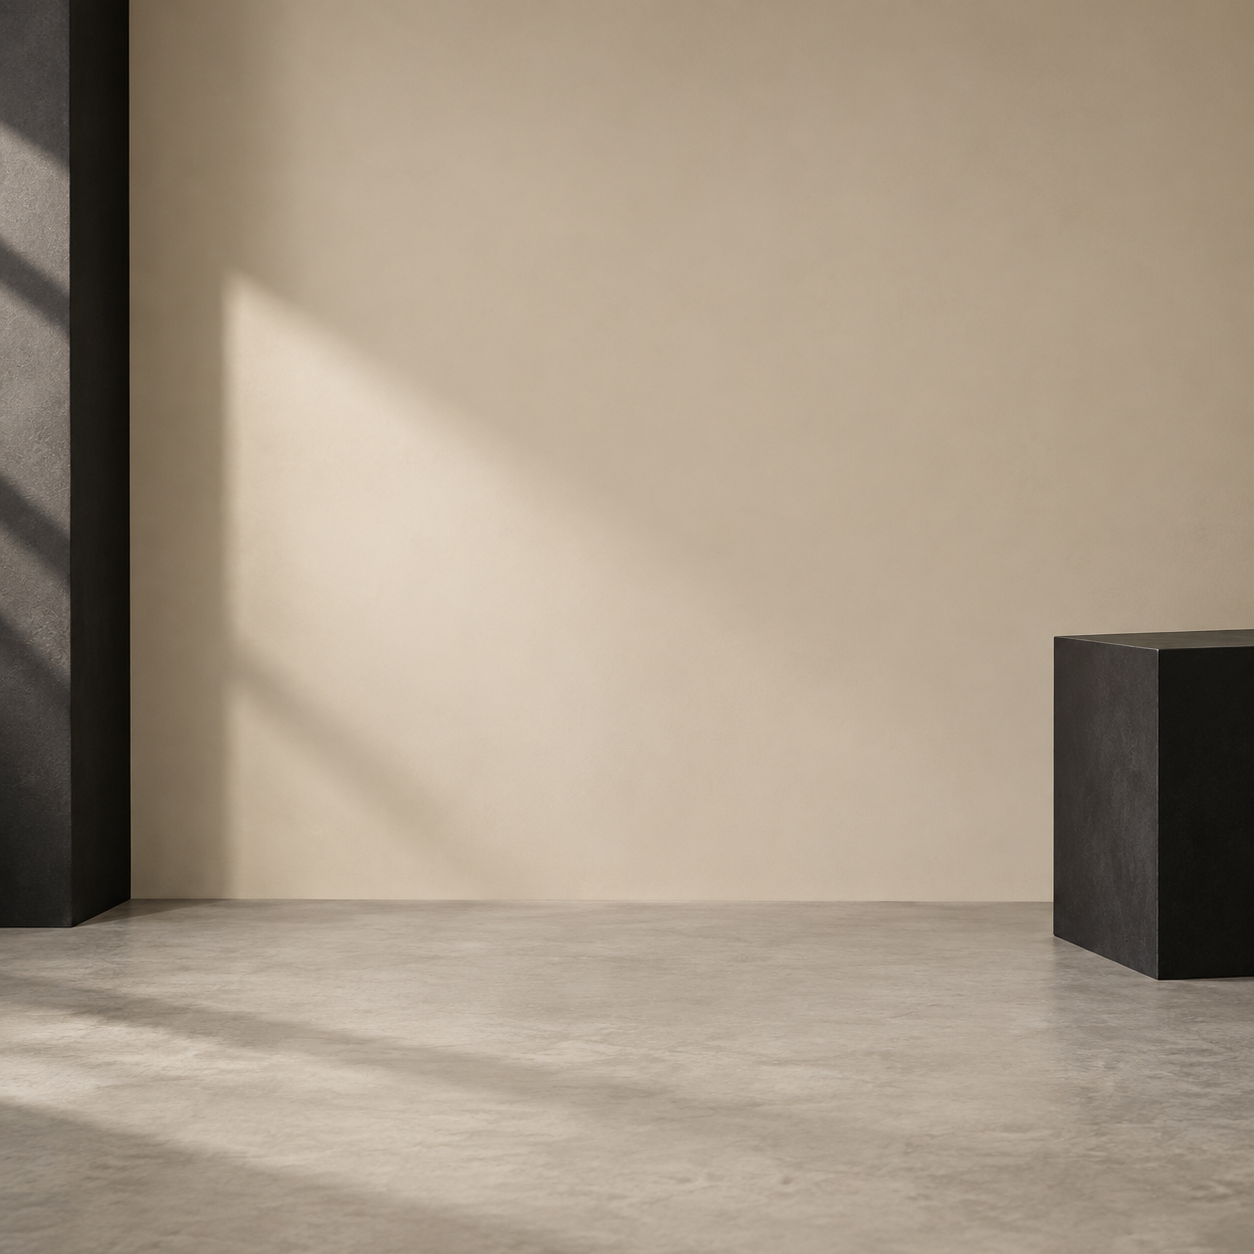

La imagen deja espacio central y mantiene una paleta neutra. Incluye un elemento vertical oscuro a la izquierda que no se solicitó. Un ajuste posible es agregar “sin columnas ni elementos verticales adicionales”. Ese ajuste se propone, pero no se afirma haberlo probado.

Para ampliar el experimento visual se pueden usar los prompts de imagen producidos por la notebook en la herramienta elegida y guardar los resultados. No se ha programado una llamada de generación de imagen en esta POC.

## 8. Análisis de resultados y conclusiones

### Revisión de las respuestas reales
Los tres resultados cumplen las cinco comprobaciones automáticas. Por lo tanto, la puntuación de formato no decide por sí sola qué texto es más útil.

| Variante | Observación de contenido | Decisión |
|---|---|---|
| A: básica | Describe la prenda como “cómoda”, atributo no confirmado por la ficha. Cumple formato y propone dos combinaciones. | Requiere quitar o verificar esa afirmación. |
| B: contexto | Mantiene los datos conocidos, propone una combinación y pide contacto. No introduce precio, tela, stock o comodidad de la prenda. | Seleccionada para esta POC tras revisión. |
| C: few-shot | Usa el tono imperativo de los ejemplos y propone pantalón gris o jean. La expresión “propuesta cómoda” es una valoración subjetiva del conjunto y merece revisión. | No mostró una ventaja clara sobre B en esta muestra. |

La variante B se selecciona por su adecuación al caso y porque necesita menos caracteres de instrucciones que C. No se deduce un ahorro exacto de tokens: la interfaz no expuso ese dato. Que A agregue un atributo no confirma que siempre lo hará, y que B no lo haga en esta prueba no garantiza que nunca invente información.

### Mejora respecto de la Preentrega 1
Se pasó del diseño de instrucciones a tres ejecuciones reales, registro de respuestas, evaluación con Python y selección fundamentada. El texto, los hashtags y la instrucción visual se obtienen en una sola respuesta. La reutilización de registros evita volver a consultar para revisar la misma evidencia.

La descomposición en funciones y la entrada manual permiten adaptar la POC sin contratar una API. La integración API sigue siendo una extensión opcional y no se afirma que se haya probado con el servicio.

### Limitaciones
Una sola respuesta por variante, un único producto y un identificador de modelo no verificable en la interfaz limitan la generalización. Se modifican varias instrucciones a la vez, por lo que no se aísla el efecto causal de cada técnica. No se midieron ahorro de tiempo, ventas, latencia de inferencia ni tokens. La revisión de contenido fue cualitativa y asistida por IA; debe ser validada por el responsable de la marca.

El flujo de generación web es **semiautomático**: se envía el prompt por la interfaz y se importa su respuesta. La notebook ejecuta la preparación, validación, comparación y exportación; no controla ChatGPT. Se documenta ese alcance sin presentarlo como una API automática.

### Resultado de la POC
Se obtuvo una comparación exploratoria real de tres configuraciones y se seleccionó B para desarrollar las otras dos publicaciones del Proyecto Final. La generación de fondos está representada por la prueba de imagen de la primera entrega y los nuevos prompts visuales; no se generaron tres imágenes nuevas en esta comparación de texto.

## Fuentes técnicas
- [OpenAI: Prompt engineering](https://developers.openai.com/api/docs/guides/prompt-engineering)
- [OpenAI: creación de respuestas, extensión opcional](https://developers.openai.com/api/reference/python/resources/responses/methods/create)

Estas referencias respaldan el diseño de instrucciones y la interfaz API. La definición operativa de Fast Prompting y las decisiones de esta POC corresponden al proyecto, no a una cita del material del curso.